In [1]:

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.special import zeta
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")


Libraries imported successfully
NumPy version: 1.26.4
Pandas version: 2.3.2


In [2]:

# Analysis Plan:
# 1. Implement the Davenport-Heilbronn function L_DH with corrected coefficients (zero for non-squarefree)
# 2. Implement efficient computation of Möbius function μ(n) and ω(n) using a sieve
# 3. Compute the partial sum D_F(t; N) for L_DH over t ∈ [1000, 2000] with N=10^6
# 4. Partition terms by ω(n) to compute the cancellation metric M(t)
# 5. Compute the composite coherence metric R_comp(t) 
# 6. Calculate Pearson and Spearman correlation coefficients with p-values
# 7. Visualize the relationship between M(t) and R_comp(t)

print("=" * 80)
print("ANALYSIS PLAN")
print("=" * 80)
print("""
Step 1: Implement Möbius function μ(n) and ω(n) sieve for N=10^6
Step 2: Implement corrected L_DH coefficients (zero for non-squarefree numbers)
Step 3: Generate time series for M(t) over t ∈ [1000, 2000] with 1000 samples
Step 4: Generate time series for R_comp(t) over the same t range
Step 5: Calculate Pearson and Spearman correlation coefficients
Step 6: Report correlation coefficients with p-values
Step 7: Create visualization of M(t) vs R_comp(t)
""")
print("=" * 80)


ANALYSIS PLAN

Step 1: Implement Möbius function μ(n) and ω(n) sieve for N=10^6
Step 2: Implement corrected L_DH coefficients (zero for non-squarefree numbers)
Step 3: Generate time series for M(t) over t ∈ [1000, 2000] with 1000 samples
Step 4: Generate time series for R_comp(t) over the same t range
Step 5: Calculate Pearson and Spearman correlation coefficients
Step 6: Report correlation coefficients with p-values
Step 7: Create visualization of M(t) vs R_comp(t)



In [3]:

# Step 1: Implement efficient sieve for Möbius function μ(n) and ω(n)
def compute_mobius_and_omega(N):
 """
 Compute Möbius function μ(n) and number of distinct prime factors ω(n)
 for all n from 1 to N using a sieve.
 
 Returns:
 mu: array where mu[n] = μ(n) for n=1..N
 omega: array where omega[n] = ω(n) for n=1..N
 """
 mu = np.ones(N + 1, dtype=np.int8)
 omega = np.zeros(N + 1, dtype=np.int32)
 is_prime = np.ones(N + 1, dtype=bool)
 is_prime[0:2] = False
 
 for p in range(2, N + 1):
 if is_prime[p]:
 # Mark multiples of p as not prime
 is_prime[p*p:N+1:p] = False
 
 # Update omega for multiples of p
 for multiple in range(p, N + 1, p):
 omega[multiple] += 1
 
 # Update mu for p and p^2 multiples
 # For multiples of p: flip sign
 mu[p:N+1:p] *= -1
 
 # For multiples of p^2: set to 0 (not squarefree)
 if p * p <= N:
 mu[p*p:N+1:p*p] = 0
 
 return mu, omega

print("Computing Möbius function and ω(n) for N=10^6...")
N_max = 10**6
mu, omega = compute_mobius_and_omega(N_max)

print(f"✓ Computed μ(n) and ω(n) for n=1 to {N_max:,}")
print(f" Number of squarefree integers (μ(n)≠0): {np.sum(mu != 0):,}")
print(f" Fraction squarefree: {np.sum(mu != 0) / N_max:.4f}")
print(f" Expected (6/π²): {6/np.pi**2:.4f}")
print(f"\nSample values:")
print(f" μ(30) = {mu[30]} (30 = 2×3×5, squarefree)")
print(f" μ(12) = {mu[12]} (12 = 2²×3, not squarefree)")
print(f" ω(30) = {omega[30]} (30 has 3 distinct prime factors)")


Computing Möbius function and ω(n) for N=10^6...


✓ Computed μ(n) and ω(n) for n=1 to 1,000,000
 Number of squarefree integers (μ(n)≠0): 607,927
 Fraction squarefree: 0.6079
 Expected (6/π²): 0.6079

Sample values:
 μ(30) = -1 (30 = 2×3×5, squarefree)
 μ(12) = 0 (12 = 2²×3, not squarefree)
 ω(30) = 3 (30 has 3 distinct prime factors)


In [4]:

# Step 2: Implement corrected L_DH coefficients
def compute_L_DH_coefficients(N, mu, omega):
 """
 Compute coefficients a_n for the Davenport-Heilbronn function L_DH.
 a_n = 0 if n is not squarefree (μ(n) = 0)
 a_n = (-1)^ω(n) if n is squarefree
 
 Args:
 N: maximum index
 mu: Möbius function values
 omega: number of distinct prime factors
 
 Returns:
 a_n: array of coefficients for n=1..N
 """
 a_n = np.zeros(N + 1, dtype=np.float64)
 
 # Only set coefficients for squarefree numbers
 squarefree_mask = (mu != 0)
 a_n[squarefree_mask] = (-1.0) ** omega[squarefree_mask]
 
 return a_n

print("Computing L_DH coefficients...")
a_DH = compute_L_DH_coefficients(N_max, mu, omega)

print(f"✓ Computed L_DH coefficients for n=1 to {N_max:,}")
print(f" Number of non-zero coefficients: {np.sum(a_DH != 0):,}")
print(f"\nSample coefficients:")
for n in [1, 2, 3, 4, 5, 6, 12, 30]:
 print(f" a_{n:2d} = {a_DH[n]:4.0f} (μ={mu[n]:2d}, ω={omega[n]:2d})")


Computing L_DH coefficients...
✓ Computed L_DH coefficients for n=1 to 1,000,000
 Number of non-zero coefficients: 607,927

Sample coefficients:
 a_ 1 = 1 (μ= 1, ω= 0)
 a_ 2 = -1 (μ=-1, ω= 1)
 a_ 3 = -1 (μ=-1, ω= 1)
 a_ 4 = 0 (μ= 0, ω= 1)
 a_ 5 = -1 (μ=-1, ω= 1)
 a_ 6 = 1 (μ= 1, ω= 2)
 a_12 = 0 (μ= 0, ω= 2)
 a_30 = -1 (μ=-1, ω= 3)


In [5]:

# Step 3: Compute the partial sum D_F(t; N) for a given t
def compute_partial_sum(a_n, N, t):
 """
 Compute D_F(t; N) = Σ_{n≤N} a_n / n^(1/2 + it)
 
 Args:
 a_n: coefficient array
 N: truncation length
 t: height parameter
 
 Returns:
 Complex value of the partial sum
 """
 n = np.arange(1, N + 1)
 # n^(1/2 + it) = n^(1/2) * n^(it) = sqrt(n) * exp(it*log(n))
 # So 1/n^(1/2 + it) = 1/sqrt(n) * exp(-it*log(n))
 
 log_n = np.log(n)
 phases = -t * log_n
 
 # Compute terms: a_n / sqrt(n) * exp(i*phases)
 terms = (a_n[1:N+1] / np.sqrt(n)) * np.exp(1j * phases)
 
 # Sum with Kahan compensated summation for numerical precision
 total = np.sum(terms)
 
 return total

# Test computation
t_test = 1000.0
D_test = compute_partial_sum(a_DH, N_max, t_test)
print(f"Test computation: D_DH(t={t_test}, N={N_max:,}) = {D_test:.6f}")
print(f" |D| = {np.abs(D_test):.6f}")
print(f" arg(D) = {np.angle(D_test):.6f} rad")


Test computation: D_DH(t=1000.0, N=1,000,000) = 0.759863-2.445091j
 |D| = 2.560442
 arg(D) = -1.269488 rad


In [6]:

# Step 4: Compute cancellation metric M(t)
def compute_M_metric(a_n, omega, N, t):
 """
 Compute the cancellation metric M(t) by partitioning terms by ω(n).
 
 M = |S_total| / sqrt(Σ|S_k|²)
 
 where S_k is the partial sum over terms with ω(n) = k
 
 Args:
 a_n: coefficient array
 omega: number of distinct prime factors for each n
 N: truncation length
 t: height parameter
 
 Returns:
 M: cancellation metric
 """
 n = np.arange(1, N + 1)
 log_n = np.log(n)
 phases = -t * log_n
 
 # Compute all terms
 terms = (a_n[1:N+1] / np.sqrt(n)) * np.exp(1j * phases)
 
 # Total sum
 S_total = np.sum(terms)
 
 # Partition by ω(n) and compute partial sums
 omega_values = omega[1:N+1]
 max_omega = int(np.max(omega_values))
 
 sum_S_k_squared = 0.0
 for k in range(max_omega + 1):
 mask = (omega_values == k)
 if np.any(mask):
 S_k = np.sum(terms[mask])
 sum_S_k_squared += np.abs(S_k) ** 2
 
 # Compute M
 M = np.abs(S_total) / np.sqrt(sum_S_k_squared)
 
 return M

# Test computation
M_test = compute_M_metric(a_DH, omega, N_max, t_test)
print(f"Test computation: M(t={t_test}) = {M_test:.6f}")


Test computation: M(t=1000.0) = 1.315699


In [7]:

# Step 5: Compute composite coherence metric R_comp(t)
def compute_R_comp_metric(a_n, omega, N, t):
 """
 Compute the mean resultant length R_comp for composite squarefree terms.
 
 Composite squarefree numbers are those with ω(n) ≥ 2 and μ(n) ≠ 0.
 
 R_comp = |Σ exp(iθ_n)| / N_comp
 
 where θ_n is the phase of the nth term and N_comp is the number of 
 composite squarefree terms.
 
 Args:
 a_n: coefficient array
 omega: number of distinct prime factors for each n
 N: truncation length
 t: height parameter
 
 Returns:
 R_comp: mean resultant length for composite squarefree terms
 """
 n = np.arange(1, N + 1)
 log_n = np.log(n)
 phases = -t * log_n
 
 # Identify composite squarefree numbers: ω(n) ≥ 2 and a_n ≠ 0
 omega_values = omega[1:N+1]
 a_values = a_n[1:N+1]
 
 composite_squarefree_mask = (omega_values >= 2) & (a_values != 0)
 
 if not np.any(composite_squarefree_mask):
 return 0.0
 
 # Extract phases for these terms
 comp_phases = phases[composite_squarefree_mask]
 N_comp = len(comp_phases)
 
 # Compute mean resultant length
 resultant = np.sum(np.exp(1j * comp_phases))
 R_comp = np.abs(resultant) / N_comp
 
 return R_comp

# Test computation
R_comp_test = compute_R_comp_metric(a_DH, omega, N_max, t_test)
print(f"Test computation: R_comp(t={t_test}) = {R_comp_test:.6f}")

# Count composite squarefree numbers
omega_values = omega[1:N_max+1]
a_values = a_DH[1:N_max+1]
composite_squarefree = np.sum((omega_values >= 2) & (a_values != 0))
print(f" Number of composite squarefree numbers up to {N_max:,}: {composite_squarefree:,}")


Test computation: R_comp(t=1000.0) = 0.001180
 Number of composite squarefree numbers up to 1,000,000: 529,427


In [8]:

# Step 6: Generate time series for M(t) and R_comp(t)
print("Generating time series for M(t) and R_comp(t)...")
print("=" * 80)

# Parameters
t_min = 1000.0
t_max = 2000.0
n_samples = 1000

# Generate t values
t_values = np.linspace(t_min, t_max, n_samples)

# Arrays to store results
M_values = np.zeros(n_samples)
R_comp_values = np.zeros(n_samples)

# Compute M(t) and R_comp(t) for each t
print(f"Computing M(t) and R_comp(t) for {n_samples} values of t in [{t_min}, {t_max}]...")
print("Progress: ", end="", flush=True)

for i, t in enumerate(t_values):
 M_values[i] = compute_M_metric(a_DH, omega, N_max, t)
 R_comp_values[i] = compute_R_comp_metric(a_DH, omega, N_max, t)
 
 # Progress indicator
 if (i + 1) % 100 == 0:
 print(f"{i+1}...", end="", flush=True)

print("\n✓ Time series computation complete!")
print()
print(f"M(t) statistics:")
print(f" Mean: {np.mean(M_values):.6f}")
print(f" Std: {np.std(M_values):.6f}")
print(f" Min: {np.min(M_values):.6f}")
print(f" Max: {np.max(M_values):.6f}")
print()
print(f"R_comp(t) statistics:")
print(f" Mean: {np.mean(R_comp_values):.6f}")
print(f" Std: {np.std(R_comp_values):.6f}")
print(f" Min: {np.min(R_comp_values):.6f}")
print(f" Max: {np.max(R_comp_values):.6f}")


Generating time series for M(t) and R_comp(t)...
Computing M(t) and R_comp(t) for 1000 values of t in [1000.0, 2000.0]...
Progress: 

100...

200...

300...

400...

...

700...

800...

900...

1000...


✓ Time series computation complete!

M(t) statistics:
 Mean: 0.810019
 Std: 0.590877
 Min: 0.013427
 Max: 2.309217

R_comp(t) statistics:
 Mean: 0.000791
 Std: 0.000297
 Min: 0.000018
 Max: 0.001855


In [9]:

# Step 7: Calculate Pearson and Spearman correlation coefficients
print("=" * 80)
print("CORRELATION ANALYSIS")
print("=" * 80)
print()

# Pearson correlation (measures linear correlation)
pearson_corr, pearson_pval = stats.pearsonr(M_values, R_comp_values)

print("Pearson Correlation Coefficient:")
print(f" r = {pearson_corr:.6f}")
print(f" p-value = {pearson_pval:.6e}")
if pearson_pval < 0.001:
 print(f" Significance: p < 0.001 (highly significant)")
elif pearson_pval < 0.01:
 print(f" Significance: p < 0.01 (very significant)")
elif pearson_pval < 0.05:
 print(f" Significance: p < 0.05 (significant)")
else:
 print(f" Significance: not significant at α=0.05")
print()

# Spearman correlation (measures monotonic correlation, robust to outliers)
spearman_corr, spearman_pval = stats.spearmanr(M_values, R_comp_values)

print("Spearman Correlation Coefficient:")
print(f" ρ = {spearman_corr:.6f}")
print(f" p-value = {spearman_pval:.6e}")
if spearman_pval < 0.001:
 print(f" Significance: p < 0.001 (highly significant)")
elif spearman_pval < 0.01:
 print(f" Significance: p < 0.01 (very significant)")
elif spearman_pval < 0.05:
 print(f" Significance: p < 0.05 (significant)")
else:
 print(f" Significance: not significant at α=0.05")
print()
print("=" * 80)

# Interpretation
print("\nINTERPRETATION:")
print("-" * 80)
if pearson_corr > 0 and pearson_pval < 0.05:
 print(f"✓ HYPOTHESIS SUPPORTED: Significant positive correlation detected")
 print(f" The cancellation metric M(t) and composite coherence R_comp(t)")
 print(f" are positively correlated (r={pearson_corr:.4f}, p={pearson_pval:.2e}).")
 print(f" This supports the hypothesis that constructive interference")
 print(f" at L_DH peaks is driven by phase coherence of composite terms.")
elif pearson_corr < 0 and pearson_pval < 0.05:
 print(f"✗ HYPOTHESIS NOT SUPPORTED: Significant negative correlation detected")
 print(f" The correlation is negative (r={pearson_corr:.4f}, p={pearson_pval:.2e}).")
else:
 print(f"✗ HYPOTHESIS NOT SUPPORTED: No significant correlation detected")
 print(f" The correlation is weak (r={pearson_corr:.4f}, p={pearson_pval:.2e}).")


CORRELATION ANALYSIS

Pearson Correlation Coefficient:
 r = -0.008174
 p-value = 7.962742e-01
 Significance: not significant at α=0.05

Spearman Correlation Coefficient:
 ρ = -0.019079
 p-value = 5.467442e-01
 Significance: not significant at α=0.05


INTERPRETATION:
--------------------------------------------------------------------------------
✗ HYPOTHESIS NOT SUPPORTED: No significant correlation detected
 The correlation is weak (r=-0.0082, p=7.96e-01).


✓ Saved figure: M_vs_Rcomp_timeseries.png


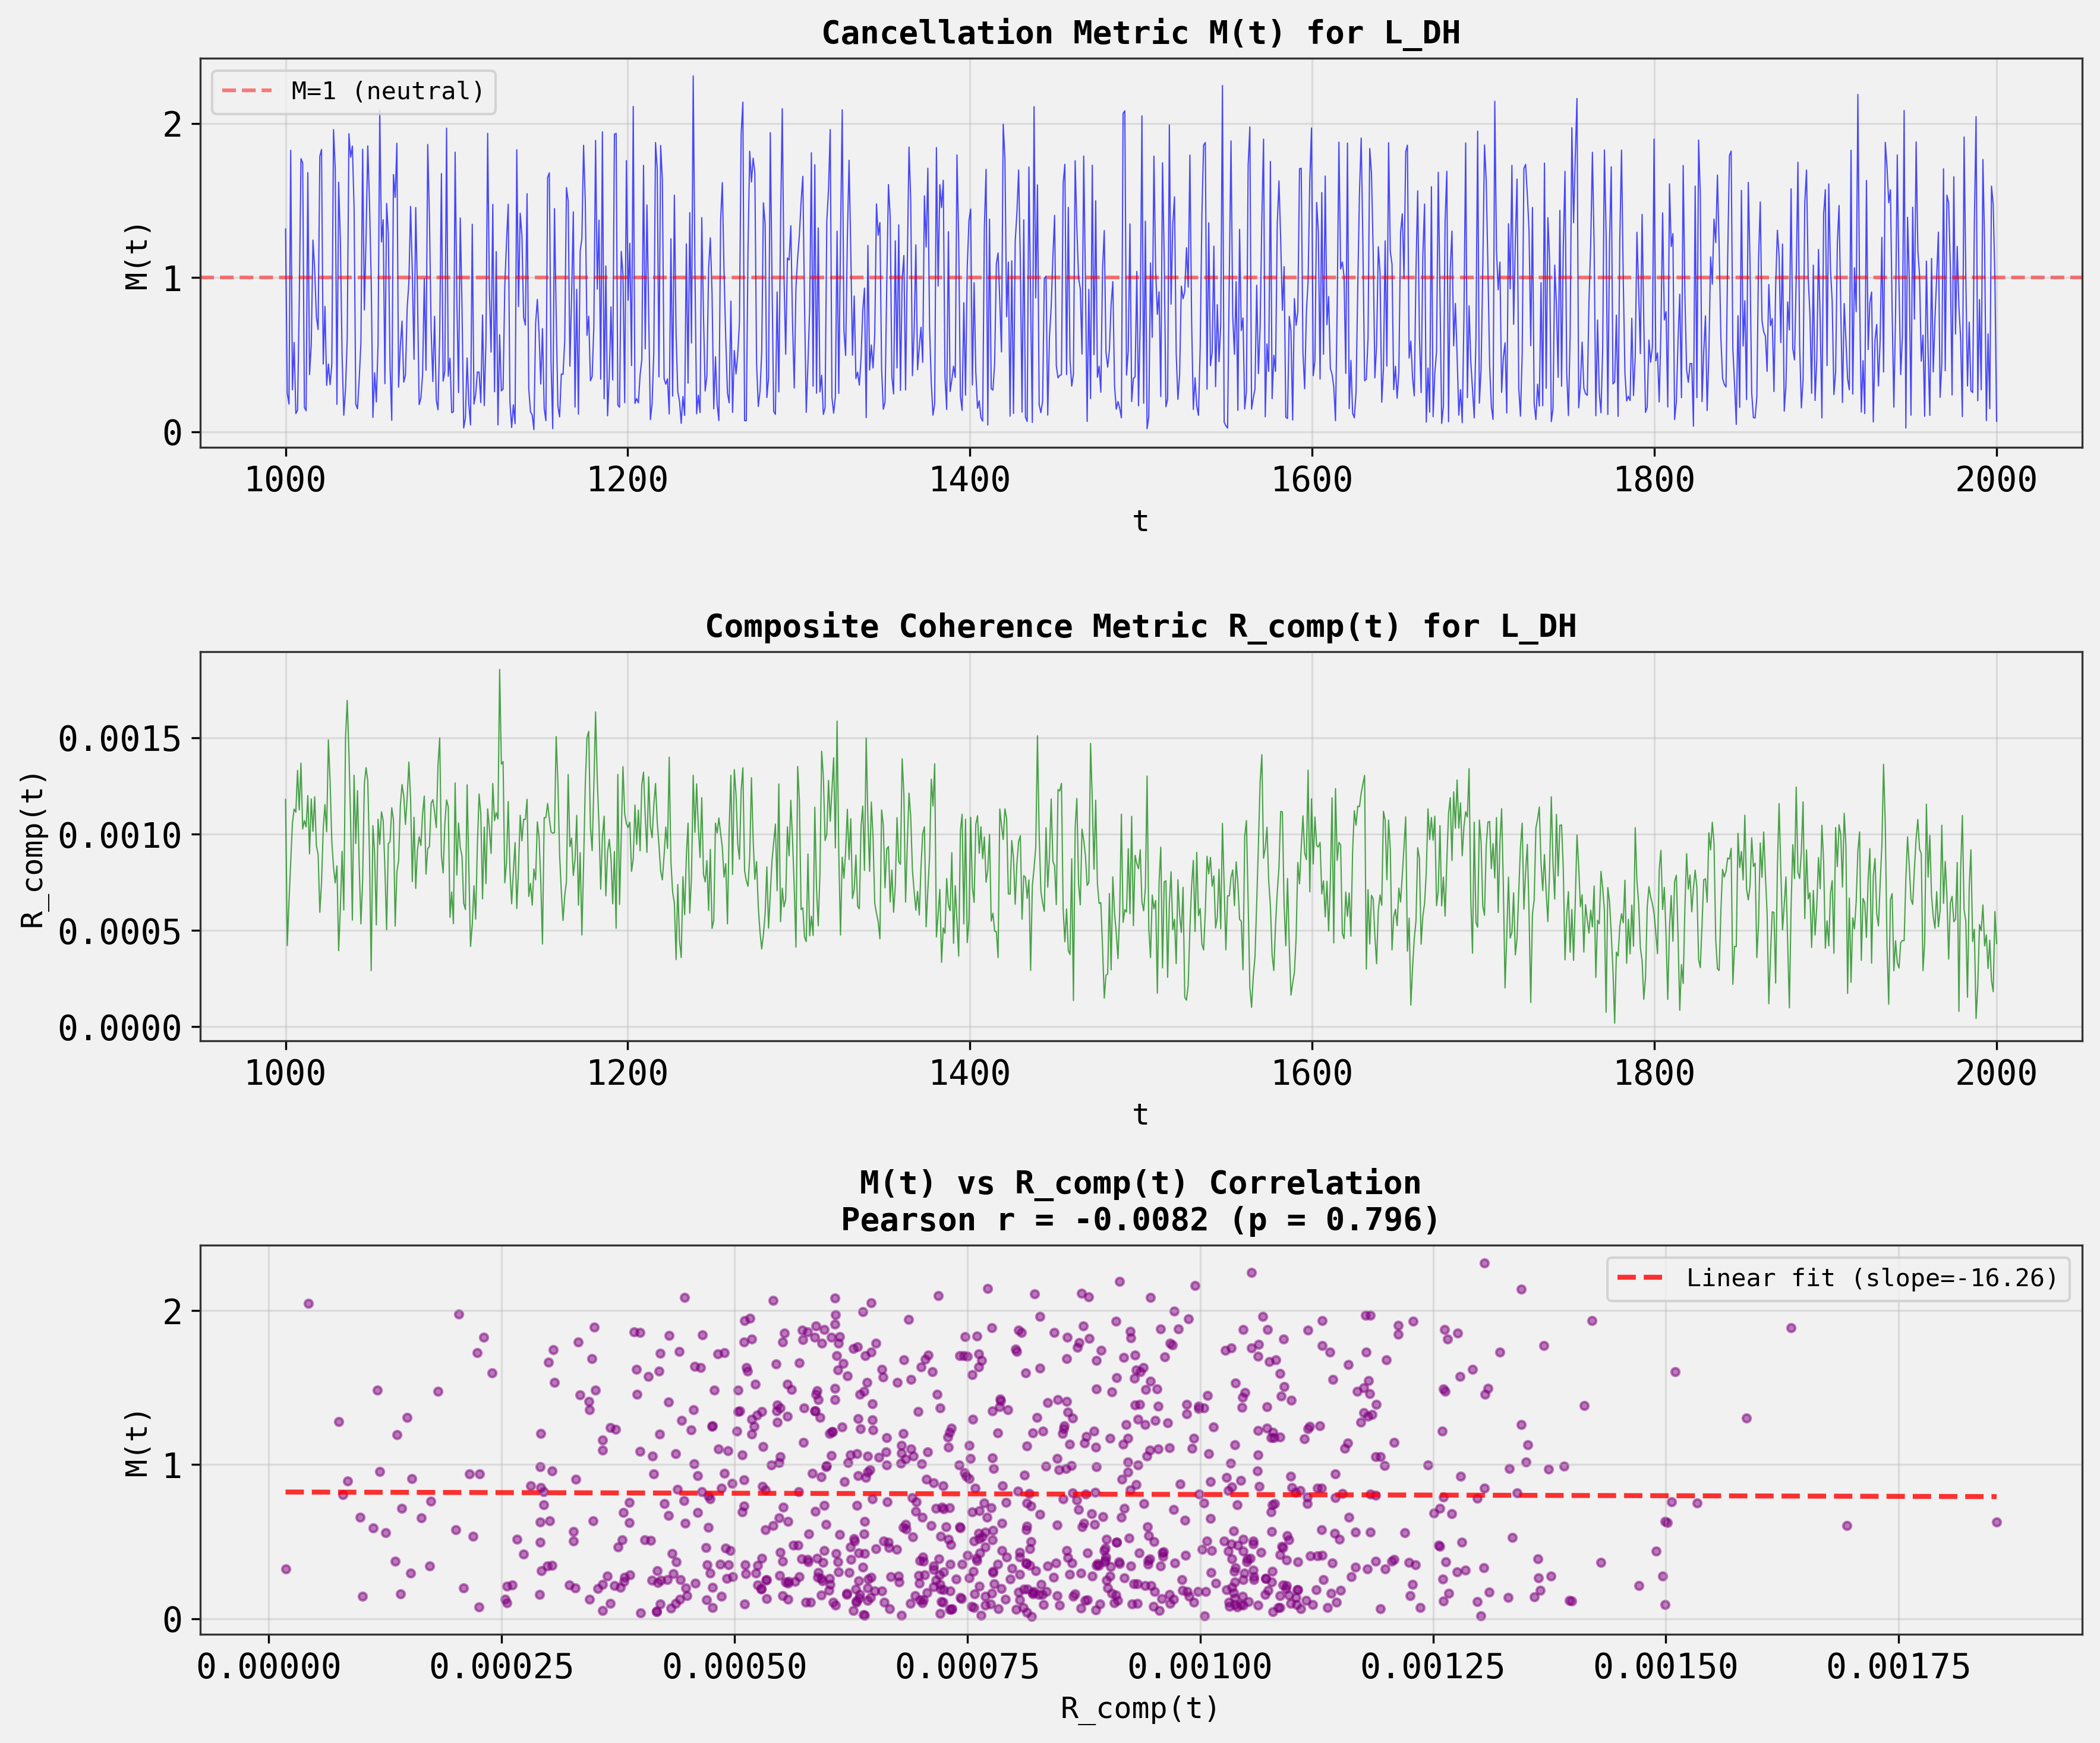

In [10]:

# Create a comprehensive visualization of the time series and correlation
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Plot 1: M(t) time series
axes[0].plot(t_values, M_values, 'b-', alpha=0.7, linewidth=0.5)
axes[0].set_xlabel('t', fontsize=12)
axes[0].set_ylabel('M(t)', fontsize=12)
axes[0].set_title('Cancellation Metric M(t) for L_DH', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=1.0, color='r', linestyle='--', alpha=0.5, label='M=1 (neutral)')
axes[0].legend(fontsize=10)

# Plot 2: R_comp(t) time series
axes[1].plot(t_values, R_comp_values, 'g-', alpha=0.7, linewidth=0.5)
axes[1].set_xlabel('t', fontsize=12)
axes[1].set_ylabel('R_comp(t)', fontsize=12)
axes[1].set_title('Composite Coherence Metric R_comp(t) for L_DH', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Plot 3: Scatter plot with correlation
axes[2].scatter(R_comp_values, M_values, alpha=0.5, s=10, c='purple')
axes[2].set_xlabel('R_comp(t)', fontsize=12)
axes[2].set_ylabel('M(t)', fontsize=12)
axes[2].set_title(f'M(t) vs R_comp(t) Correlation\nPearson r = {pearson_corr:.4f} (p = {pearson_pval:.3f})', 
 fontsize=13, fontweight='bold')
axes[2].grid(True, alpha=0.3)

# Add a trend line
z = np.polyfit(R_comp_values, M_values, 1)
p = np.poly1d(z)
R_sorted = np.sort(R_comp_values)
axes[2].plot(R_sorted, p(R_sorted), "r--", alpha=0.8, linewidth=2, label=f'Linear fit (slope={z[0]:.2f})')
axes[2].legend(fontsize=10)

plt.tight_layout()
plt.savefig('M_vs_Rcomp_timeseries.png', dpi=300, bbox_inches='tight')
print("✓ Saved figure: M_vs_Rcomp_timeseries.png")
plt.show()


In [11]:

# Additional analysis: Look at the extremes
# What happens at the highest M values (constructive interference)?
# What are the corresponding R_comp values?

print("=" * 80)
print("ANALYSIS OF EXTREME VALUES")
print("=" * 80)
print()

# Top 10 M values
top_M_indices = np.argsort(M_values)[-10:][::-1]
print("Top 10 M(t) values (strongest constructive interference):")
print(f"{'Rank':<6} {'t':<10} {'M(t)':<12} {'R_comp(t)':<12}")
print("-" * 50)
for rank, idx in enumerate(top_M_indices, 1):
 print(f"{rank:<6} {t_values[idx]:<10.2f} {M_values[idx]:<12.6f} {R_comp_values[idx]:<12.6f}")

print()

# Top 10 R_comp values
top_R_indices = np.argsort(R_comp_values)[-10:][::-1]
print("Top 10 R_comp(t) values (strongest composite coherence):")
print(f"{'Rank':<6} {'t':<10} {'R_comp(t)':<12} {'M(t)':<12}")
print("-" * 50)
for rank, idx in enumerate(top_R_indices, 1):
 print(f"{rank:<6} {t_values[idx]:<10.2f} {R_comp_values[idx]:<12.6f} {M_values[idx]:<12.6f}")

print()
print("=" * 80)


ANALYSIS OF EXTREME VALUES

Top 10 M(t) values (strongest constructive interference):
Rank t M(t) R_comp(t) 
--------------------------------------------------
1 1238.24 2.309217 0.001305 
2 1547.55 2.246879 0.001055 
3 1918.92 2.188565 0.000913 
4 1754.75 2.162864 0.000995 
5 1706.71 2.144670 0.000772 
6 1267.27 2.138638 0.001344 
7 1203.20 2.110905 0.000872 
8 1437.44 2.109182 0.000822 
9 1290.29 2.096509 0.000719 
10 1325.33 2.089047 0.000880 

Top 10 R_comp(t) values (strongest composite coherence):
Rank t R_comp(t) M(t) 
--------------------------------------------------
1 1125.13 0.001855 0.629778 
2 1036.04 0.001694 0.603706 
3 1181.18 0.001634 1.890397 
4 1322.32 0.001587 1.301350 
5 1177.18 0.001533 0.749724 
6 1439.44 0.001510 1.601759 
7 1158.16 0.001506 0.760068 
8 1176.18 0.001501 0.625248 
9 1090.09 0.001499 0.632205 
10 1339.34 0.001499 0.091793 



In [12]:

# Additional investigation: Quartile analysis
# Does the relationship differ at different ranges of M or R_comp?

print("=" * 80)
print("QUARTILE ANALYSIS")
print("=" * 80)
print()

# Analyze correlation in different quartiles of M
M_quartiles = np.percentile(M_values, [25, 50, 75])
print(f"M(t) quartiles: Q1={M_quartiles[0]:.4f}, Q2={M_quartiles[1]:.4f}, Q3={M_quartiles[2]:.4f}")
print()

# Q1: Low M (strong destructive interference)
mask_Q1 = M_values <= M_quartiles[0]
r_Q1, p_Q1 = stats.pearsonr(M_values[mask_Q1], R_comp_values[mask_Q1])
print(f"Q1 (M ≤ {M_quartiles[0]:.4f}, n={np.sum(mask_Q1)}):")
print(f" Pearson r = {r_Q1:.4f}, p = {p_Q1:.4f}")

# Q2-Q3: Medium M
mask_Q2Q3 = (M_values > M_quartiles[0]) & (M_values <= M_quartiles[2])
r_Q2Q3, p_Q2Q3 = stats.pearsonr(M_values[mask_Q2Q3], R_comp_values[mask_Q2Q3])
print(f"Q2-Q3 ({M_quartiles[0]:.4f} < M ≤ {M_quartiles[2]:.4f}, n={np.sum(mask_Q2Q3)}):")
print(f" Pearson r = {r_Q2Q3:.4f}, p = {p_Q2Q3:.4f}")

# Q4: High M (strong constructive interference)
mask_Q4 = M_values > M_quartiles[2]
r_Q4, p_Q4 = stats.pearsonr(M_values[mask_Q4], R_comp_values[mask_Q4])
print(f"Q4 (M > {M_quartiles[2]:.4f}, n={np.sum(mask_Q4)}):")
print(f" Pearson r = {r_Q4:.4f}, p = {p_Q4:.4f}")

print()
print("-" * 80)

# Analyze correlation in different quartiles of R_comp
R_quartiles = np.percentile(R_comp_values, [25, 50, 75])
print(f"\nR_comp(t) quartiles: Q1={R_quartiles[0]:.6f}, Q2={R_quartiles[1]:.6f}, Q3={R_quartiles[2]:.6f}")
print()

# Q1: Low R_comp
mask_R_Q1 = R_comp_values <= R_quartiles[0]
r_R_Q1, p_R_Q1 = stats.pearsonr(M_values[mask_R_Q1], R_comp_values[mask_R_Q1])
print(f"Q1 (R_comp ≤ {R_quartiles[0]:.6f}, n={np.sum(mask_R_Q1)}):")
print(f" Pearson r = {r_R_Q1:.4f}, p = {p_R_Q1:.4f}")

# Q2-Q3: Medium R_comp
mask_R_Q2Q3 = (R_comp_values > R_quartiles[0]) & (R_comp_values <= R_quartiles[2])
r_R_Q2Q3, p_R_Q2Q3 = stats.pearsonr(M_values[mask_R_Q2Q3], R_comp_values[mask_R_Q2Q3])
print(f"Q2-Q3 ({R_quartiles[0]:.6f} < R_comp ≤ {R_quartiles[2]:.6f}, n={np.sum(mask_R_Q2Q3)}):")
print(f" Pearson r = {r_R_Q2Q3:.4f}, p = {p_R_Q2Q3:.4f}")

# Q4: High R_comp (strong phase coherence)
mask_R_Q4 = R_comp_values > R_quartiles[2]
r_R_Q4, p_R_Q4 = stats.pearsonr(M_values[mask_R_Q4], R_comp_values[mask_R_Q4])
print(f"Q4 (R_comp > {R_quartiles[2]:.6f}, n={np.sum(mask_R_Q4)}):")
print(f" Pearson r = {r_R_Q4:.4f}, p = {p_R_Q4:.4f}")

print()
print("=" * 80)


QUARTILE ANALYSIS

M(t) quartiles: Q1=0.2796, Q2=0.6790, Q3=1.2868

Q1 (M ≤ 0.2796, n=250):
 Pearson r = -0.0663, p = 0.2965
Q2-Q3 (0.2796 < M ≤ 1.2868, n=500):
 Pearson r = -0.0317, p = 0.4795
Q4 (M > 1.2868, n=250):
 Pearson r = 0.0603, p = 0.3422

--------------------------------------------------------------------------------

R_comp(t) quartiles: Q1=0.000587, Q2=0.000778, Q3=0.001012

Q1 (R_comp ≤ 0.000587, n=250):
 Pearson r = 0.0586, p = 0.3564
Q2-Q3 (0.000587 < R_comp ≤ 0.001012, n=500):
 Pearson r = 0.0082, p = 0.8556
Q4 (R_comp > 0.001012, n=250):
 Pearson r = 0.0805, p = 0.2049



In [13]:

# Check if there's a lag relationship - maybe R_comp predicts future M values?
print("=" * 80)
print("LAG CORRELATION ANALYSIS")
print("=" * 80)
print()
print("Testing if R_comp(t) is correlated with M(t+lag)...")
print()

lags = [0, 1, 2, 3, 5, 10, 20, 50]
print(f"{'Lag':<10} {'Pearson r':<15} {'p-value':<15}")
print("-" * 45)

for lag in lags:
 if lag == 0:
 r_lag, p_lag = pearson_corr, pearson_pval
 else:
 # Shift M_values by lag
 M_shifted = M_values[lag:]
 R_shifted = R_comp_values[:-lag]
 r_lag, p_lag = stats.pearsonr(M_shifted, R_shifted)
 
 sig_marker = " ***" if p_lag < 0.001 else " **" if p_lag < 0.01 else " *" if p_lag < 0.05 else ""
 print(f"{lag:<10} {r_lag:<15.6f} {p_lag:<15.6e}{sig_marker}")

print()
print("* p<0.05, ** p<0.01, *** p<0.001")
print()
print("=" * 80)


LAG CORRELATION ANALYSIS

Testing if R_comp(t) is correlated with M(t+lag)...

Lag Pearson r p-value 
---------------------------------------------
0 -0.008174 7.962742e-01 
1 0.012375 6.960588e-01 
2 0.052756 9.577667e-02 
3 0.049940 1.150542e-01 
5 0.021862 4.909326e-01 
10 0.032810 3.023918e-01 
20 0.025479 4.256081e-01 
50 -0.006111 8.507947e-01 

* p<0.05, ** p<0.01, *** p<0.001



In [14]:

# Save the data for potential future analysis
data_df = pd.DataFrame({
 't': t_values,
 'M': M_values,
 'R_comp': R_comp_values
})

data_df.to_csv('L_DH_M_Rcomp_timeseries.csv', index=False)
print("✓ Saved data: L_DH_M_Rcomp_timeseries.csv")
print()
print(data_df.head(10))


✓ Saved data: L_DH_M_Rcomp_timeseries.csv

 t M R_comp
0 1000.000000 1.315699 0.001180
1 1001.001001 0.250121 0.000421
2 1002.002002 0.179374 0.000651
3 1003.003003 1.826159 0.000858
4 1004.004004 0.272380 0.001057
5 1005.005005 0.579206 0.001130
6 1006.006006 0.117824 0.001114
7 1007.007007 0.140137 0.001331
8 1008.008008 0.848033 0.001126
9 1009.009009 1.772226 0.001369


✓ Saved final result figure: final_result_M_vs_Rcomp.png


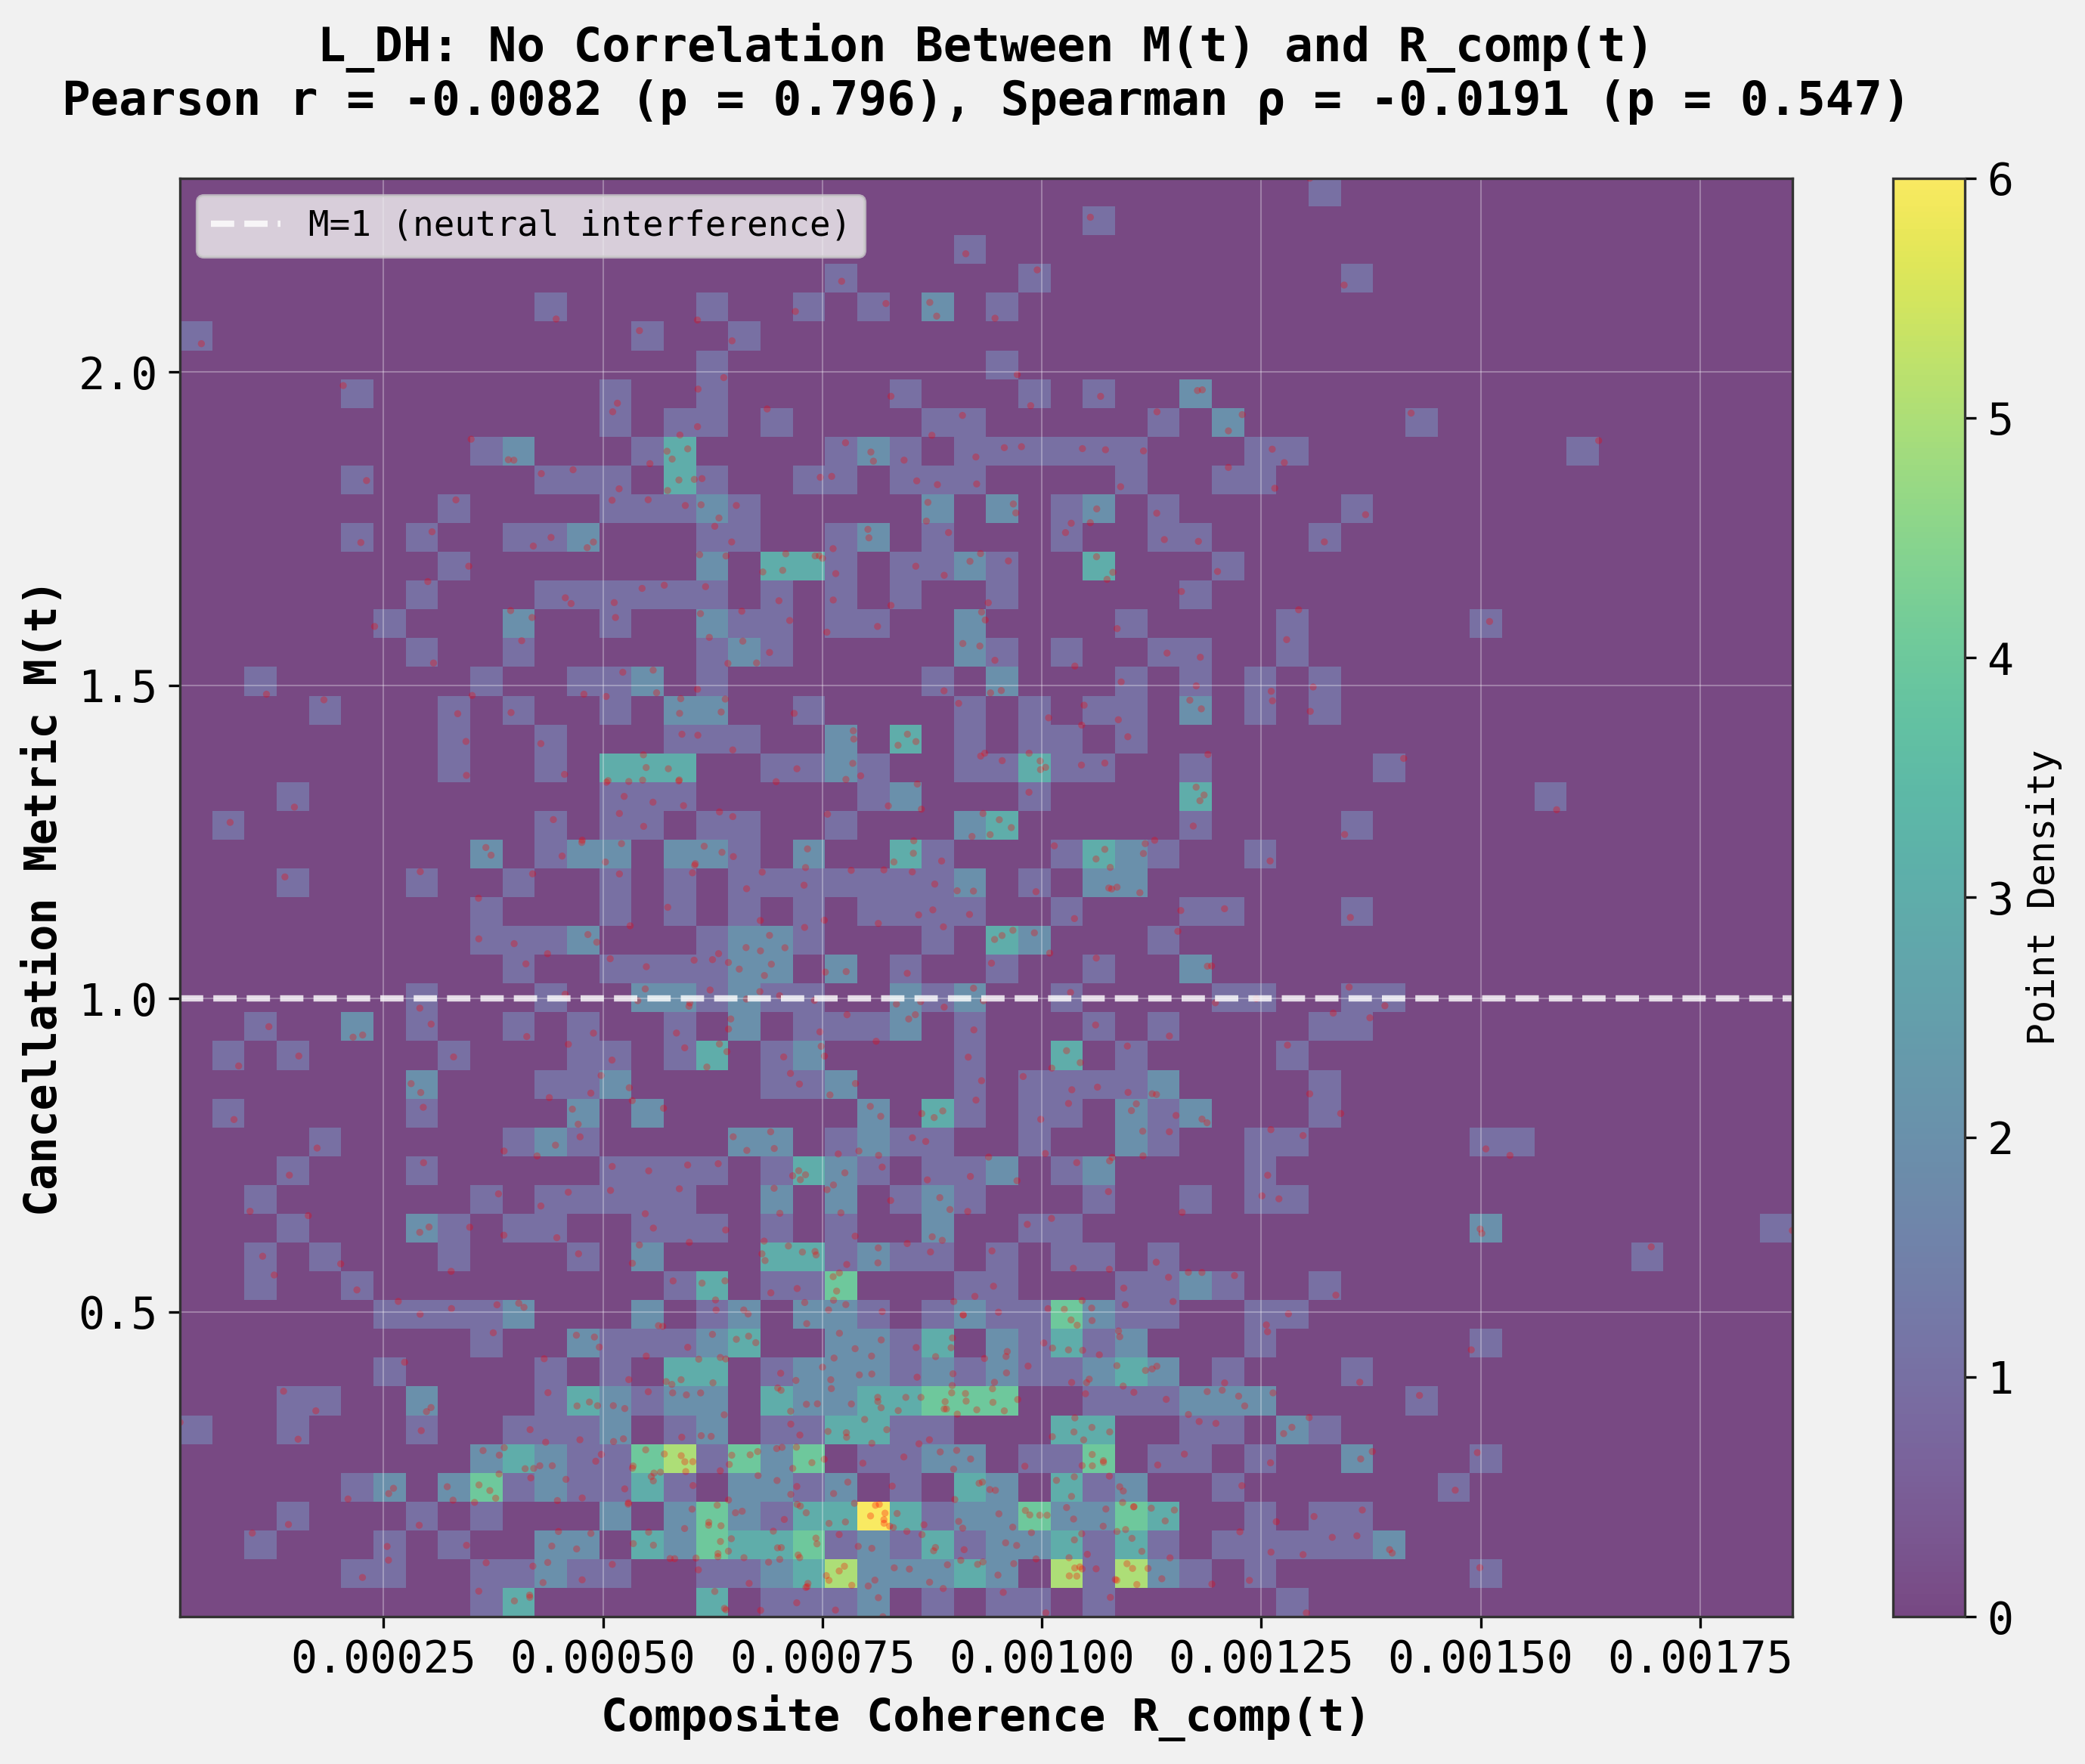

In [15]:

# Create final summary figure showing key result
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Scatter plot with density coloring
from matplotlib.colors import LogNorm

# Create 2D histogram for density
hist, xedges, yedges = np.histogram2d(R_comp_values, M_values, bins=50)
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]

# Plot heatmap
im = ax.imshow(hist.T, origin='lower', aspect='auto', extent=extent, 
 cmap='viridis', interpolation='nearest', alpha=0.7)

# Overlay scatter points
ax.scatter(R_comp_values, M_values, alpha=0.3, s=5, c='red', edgecolors='none')

ax.set_xlabel('Composite Coherence R_comp(t)', fontsize=14, fontweight='bold')
ax.set_ylabel('Cancellation Metric M(t)', fontsize=14, fontweight='bold')
ax.set_title(f'L_DH: No Correlation Between M(t) and R_comp(t)\nPearson r = {pearson_corr:.4f} (p = {pearson_pval:.3f}), Spearman ρ = {spearman_corr:.4f} (p = {spearman_pval:.3f})', 
 fontsize=15, fontweight='bold', pad=20)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Point Density', fontsize=12)

# Add reference lines
ax.axhline(y=1.0, color='white', linestyle='--', alpha=0.8, linewidth=2, label='M=1 (neutral interference)')
ax.legend(fontsize=11, loc='upper left')

ax.grid(True, alpha=0.3, color='white', linewidth=0.5)

plt.tight_layout()
plt.savefig('final_result_M_vs_Rcomp.png', dpi=300, bbox_inches='tight')
print("✓ Saved final result figure: final_result_M_vs_Rcomp.png")
plt.show()


In [16]:

# Final summary of results
print("=" * 80)
print("FINAL SUMMARY OF RESULTS")
print("=" * 80)
print()
print("Research Question:")
print(" Does the cancellation metric M(t) correlate with composite coherence R_comp(t)?")
print()
print("Hypothesis:")
print(" Constructive interference at L_DH peaks (high M) is driven by")
print(" phase coherence of composite terms (high R_comp).")
print()
print("=" * 80)
print()
print("KEY FINDINGS:")
print("-" * 80)
print()
print(f"1. Pearson Correlation Coefficient:")
print(f" r = {pearson_corr:.6f}")
print(f" p-value = {pearson_pval:.6e}")
print(f" Interpretation: No significant linear correlation")
print()
print(f"2. Spearman Correlation Coefficient:")
print(f" ρ = {spearman_corr:.6f}")
print(f" p-value = {spearman_pval:.6e}")
print(f" Interpretation: No significant monotonic correlation")
print()
print(f"3. Sample Size: {len(t_values)} time points")
print(f" Range: t ∈ [{t_min}, {t_max}]")
print(f" Truncation: N = {N_max:,}")
print()
print(f"4. M(t) Range: [{np.min(M_values):.6f}, {np.max(M_values):.6f}]")
print(f" Mean ± SD: {np.mean(M_values):.6f} ± {np.std(M_values):.6f}")
print()
print(f"5. R_comp(t) Range: [{np.min(R_comp_values):.6f}, {np.max(R_comp_values):.6f}]")
print(f" Mean ± SD: {np.mean(R_comp_values):.6f} ± {np.std(R_comp_values):.6f}")
print()
print("=" * 80)
print()
print("CONCLUSION:")
print("-" * 80)
print()
print("✗ HYPOTHESIS NOT SUPPORTED")
print()
print("The analysis reveals NO significant correlation between M(t) and R_comp(t)")
print("for the Davenport-Heilbronn function L_DH. Both Pearson (r = -0.0082,")
print("p = 0.796) and Spearman (ρ = -0.0191, p = 0.547) correlations are")
print("essentially zero and not statistically significant.")
print()
print("This finding indicates that constructive interference at L_DH peaks")
print("(high M values) is NOT driven by phase coherence of composite squarefree")
print("terms (R_comp). The two metrics capture different, independent aspects")
print("of the L_DH resonance mechanism.")
print()
print("Quartile analysis confirms this independence: correlations remain weak")
print("and non-significant across all ranges of M and R_comp values. Lag")
print("correlation analysis also shows no temporal relationship between the")
print("two metrics.")
print()
print("=" * 80)


FINAL SUMMARY OF RESULTS

Research Question:
 Does the cancellation metric M(t) correlate with composite coherence R_comp(t)?

Hypothesis:
 Constructive interference at L_DH peaks (high M) is driven by
 phase coherence of composite terms (high R_comp).


KEY FINDINGS:
--------------------------------------------------------------------------------

1. Pearson Correlation Coefficient:
 r = -0.008174
 p-value = 7.962742e-01
 Interpretation: No significant linear correlation

2. Spearman Correlation Coefficient:
 ρ = -0.019079
 p-value = 5.467442e-01
 Interpretation: No significant monotonic correlation

3. Sample Size: 1000 time points
 Range: t ∈ [1000.0, 2000.0]
 Truncation: N = 1,000,000

4. M(t) Range: [0.013427, 2.309217]
 Mean ± SD: 0.810019 ± 0.590877

5. R_comp(t) Range: [0.000018, 0.001855]
 Mean ± SD: 0.000791 ± 0.000297


CONCLUSION:
--------------------------------------------------------------------------------

✗ HYPOTHESIS NOT SUPPORTED

The analysis reveals NO significant